실습1. 변화량으로 급변 탐지하기
- 원본에서 안 보이던 급변 시점을 변화량으로 찾기

목표
- 직전 대비 변화량으로 원본에서 안 보이던 급변 시점을 찾기

단계
- 2번 엔진 센서의 직전 대비 변화량을 구하기
- 위칸에 원본, 아래칸에 변화량과 0 기준선을 그리기
- 0에서 크게 벗어난 회차를 급변 시점으로 표시

예상 결과
- 변화량 그래프에서 0을 크게 벗어난 몇몇 회차가 급변 후보

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv("../data/21_cmapss_fd001_sample.csv")

(287, 10)


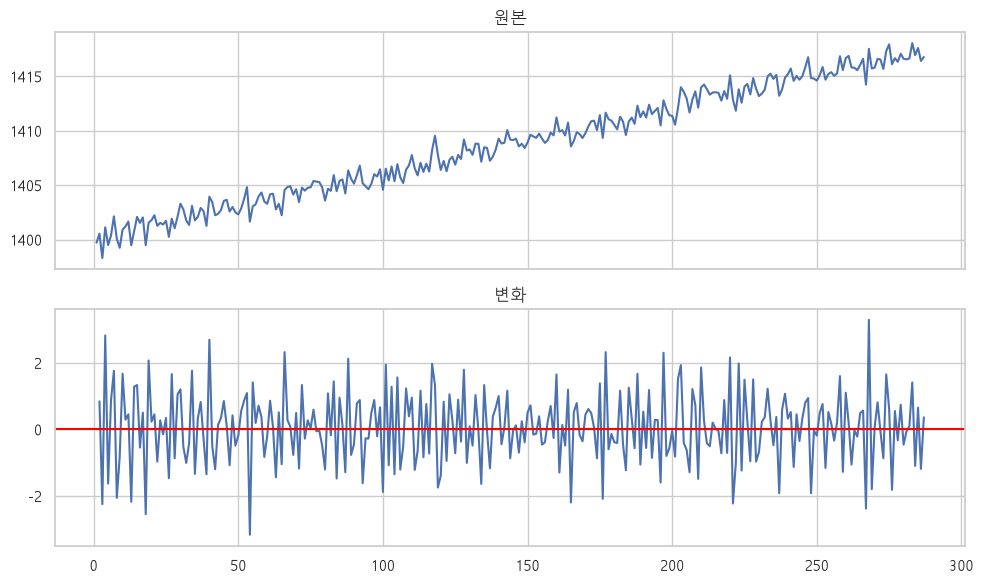

3.29


In [ ]:
eng_02 = df[df["unit_nr"] == 2]
print(eng_02.shape) # (287, 10)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

ax1.set_title("원본")
ax1.plot(eng_02["time_cycles"], eng_02["s_4"])

ax2.set_title("변화")
diff = eng_02["s_4"].diff()
ax2.plot(eng_02["time_cycles"], diff)

# 0 기준선
ax2.axhline(0, color="red")

plt.tight_layout()
plt.show()

# 급변 지점
print(round(diff.abs().max(), 2)) # 3.29